In [1]:
%matplotlib widget

import numpy as np
import pandas as pd
import os
from blackjack.actions import PlayerAction, DealerAction
from blackjack.blackjack_round import BJRound, BJStage
from blackjack_py import ProbabilisticRankShoe, RandomSampler
from blackjack.rules import BJRules
import time
import random
import tqdm

In [2]:
def fill_tc_limits(table):
    table["tc_min"] = table["tc_min"].fillna(-np.inf)
    table["tc_max"] = table["tc_max"].fillna(np.inf)

str_to_action = {
    "s": PlayerAction.STAND,
    "h": PlayerAction.HIT,
    "d": PlayerAction.DOUBLE,
    "p": PlayerAction.SPLIT,
}

def actions_str_to_list(actions_str):
    return [str_to_action[action_char] for action_char in actions_str]


class DeviationStrategy:
    def __init__(self, folder):
        hard_alt_path = os.path.join(folder, "hard_deviations.csv")
        soft_alt_path = os.path.join(folder, "soft_deviations.csv")
        pair_alt_path = os.path.join(folder, "pair_deviations.csv")
        insurance_path = os.path.join(folder, "insurance.csv")
        self.hard_alt_table = pd.read_csv(hard_alt_path)
        self.soft_alt_table = pd.read_csv(soft_alt_path)
        self.pair_alt_table = pd.read_csv(pair_alt_path)
        self.insurance_table = pd.read_csv(insurance_path)
        fill_tc_limits(self.hard_alt_table)
        fill_tc_limits(self.soft_alt_table)
        fill_tc_limits(self.pair_alt_table)
        fill_tc_limits(self.insurance_table)


    def split_action(self, card_value, dealer_value, true_count):
        """
        returns an action that should override split/no-split decision
        returns none if should stick to basic strategy
        """
        true_count_int = int(true_count)
        idx = (
            (self.pair_alt_table["card_value"] == card_value)
            & (self.pair_alt_table["dealer"] == dealer_value)
        )
        row = self.pair_alt_table.loc[idx, ["tc_min", "tc_max", "action"]].values
        if len(row) > 0:
            tc_min, tc_max, actions_str = row[0]
            if tc_min <= true_count_int <= tc_max:
                assert len(actions_str) == 1
                return actions_str_to_list(actions_str[0])
        return None
        

    def get_altiated_actions(self, player_value, is_soft, is_pair, dealer_value, true_count):
        actions = []

        true_count_int = int(true_count)
        insurance_tc_min, insurance_tc_max = self.insurance_table.loc[0, ["tc_min", "tc_max"]].values
        if insurance_tc_min <= true_count_int <= insurance_tc_max:
            actions.append(PlayerAction.TAKE_INSURANCE)
        
        if is_pair:
            split_actions = self.split_action(player_value // 2, dealer_value, true_count)
            if split_actions is not None:
                actions.extend(split_actions)
                
        if is_soft:
            dev_table = self.soft_alt_table
        else:
            dev_table = self.hard_alt_table
        
        idx = (
            dev_table["player"] == player_value
            & (dev_table["dealer"] == dealer_value)
        )
        row = dev_table.loc[idx, ["tc_min", "tc_max", "action"]].values

        if len(row) > 0:
            tc_min, tc_max, actions_str = row[0]
            if tc_min <= true_count_int <= tc_max:
                actions.extend(actions_str_to_list(actions_str))

        return actions


In [3]:
class BasicStrategy:
    def __init__(self, folder):
        hard_path = os.path.join(folder, "s17_hard.csv")
        soft_path = os.path.join(folder, "s17_soft.csv")
        split_path = os.path.join(folder, "s17_split.csv")
        self.hard_table = pd.read_csv(hard_path)
        self.soft_table = pd.read_csv(soft_path)
        self.split_table = pd.read_csv(split_path)


    def should_split(self, card_value, dealer_value):
        val_series = self.split_table.loc[
            self.split_table["card_value"] == card_value, str(dealer_value)
        ]
        assert len(val_series) == 1
        return val_series.iat[0] == "p" 


    def get_actions(self, player_value, is_soft, is_pair, dealer_value, true_count):
        actions = [PlayerAction.REFUSE_INSURANCE]
        if is_pair:
            if self.should_split(player_value // 2, dealer_value):
                actions.append(PlayerAction.SPLIT)
        
        if is_soft:
            table = self.soft_table
        else:
            table = self.hard_table

        actions_str_entry = table.loc[
            table["player"] == player_value, 
            str(dealer_value)
        ]
        assert len(actions_str_entry) == 1
        actions.extend(actions_str_to_list(actions_str_entry.iat[0]))
        return actions
    

In [4]:
class DeviatedBasicStrategy:
    def __init__(self, basic_strategy_folder, deviation_strategy_folder):
        self.basic_strategy = BasicStrategy(basic_strategy_folder)
        self.deviation_strategy = DeviationStrategy(deviation_strategy_folder)


    def get_actions(self, player_value, is_soft, is_pair, dealer_value, true_count):
        dev_actions = self.deviation_strategy.get_altiated_actions(
            player_value, is_soft, is_pair, dealer_value, true_count
        )
        
        basic_actions = self.basic_strategy.get_actions(
            player_value, is_soft, is_pair, dealer_value, true_count
        )
        return dev_actions + basic_actions

In [5]:
class Counter:
    def __init__(self, n_decks, current_penetration=0):
        self.n_decks = n_decks
        self.remaining_cards = n_decks * 52
        self.remaining_cards -= int(round(self.remaining_cards * current_penetration))
        self.running_count = 0
    
    def reset(self):
        self.remaining_cards = self.n_decks * 52
        self.running_count = 0

    def update_count(self, rank_value):
        # Tag values: 2–6 = +1, 7–9 = 0, 10–A = −1
        if rank_value < 7:
            self.running_count += 1
        elif rank_value > 9:
            self.running_count -= 1
        self.remaining_cards -= 1
    
    def get_true_count(self):
        remaining_decks = self.remaining_cards / 52
        if remaining_decks <= 0:
            return None
        return self.running_count / remaining_decks
    
    def get_integer_tc(self):
        # use integer TCs rounded toward zero
        # 1.9 -> 1 | -1.8 -> -1
        true_count = self.get_true_count()
        if true_count is None:
            return None
        return int(true_count)

In [6]:
rules = BJRules(
    dealer_checks_blackjack = True,
    dealer_hits_soft_17 = False,
    allow_late_surrender = False,
    allow_early_surrender_on_ten = False,
    allow_early_surrender_on_ace = False,
    allow_early_surrender_on_all = False,
    dealer_shows_card_on_surrender = True,
    allow_insurance_vs_ace = True,
    natural_blackjack_payout = 3 / 2,
    surrender_payout = 1 / 2,
    insurance_payout = 2 / 1,
    max_splits_allowed = 1,
    allow_action_on_split_aces = True,
    allow_double_after_split = True,
    allow_double_on_soft = True,
    allow_split_different_tens = True,
    split_order_reversed = False
)

In [7]:
def play_round(shoe, counter, bet_unit, strategy, verbose=False):
    bj_round = BJRound(rules)
    shoe.unlock_dealer_card()
    bj_round.start_round(bet_unit=bet_unit)
    dealer_second_card = None

    stage = bj_round.get_stage()

    if verbose:
        print(bj_round)

    while stage != BJStage.ROUND_OVER:
        possible_cards = bj_round.get_possible_next_card_ranks()
        possible_actions = bj_round.get_available_actions()

        if len(possible_actions) > 0:
            dealer_hand = bj_round.get_dealer_hand()
            dealer_upcard = dealer_hand[0]

            if bj_round.need_player_action():
                true_count = counter.get_true_count()
                player_hand = bj_round.get_active_player_hand()
                
                is_soft = player_hand.is_soft()
                is_pair = player_hand.is_same_value_pair()
                player_value = player_hand.get_best_value()

                actions = strategy.get_actions(
                    player_value,
                    is_soft,
                    is_pair,
                    dealer_upcard,
                    true_count
                )

                chosen_action = None
                for a in actions:
                    if a in possible_actions:
                        chosen_action = a
                        break
                assert chosen_action is not None
                bj_round.take_action(chosen_action)

            elif stage == BJStage.DEALER_CHECK_BJ:            
                if dealer_upcard == 11:  # Ace
                    second_card_needed = 10
                else:  # dealer has 10
                    second_card_needed = 11

                # all cards are possible for the second dealer's card
                # no conditioning on possible_cards
                dealer_second_card = shoe.sample_and_burn_rank()

                if dealer_upcard + dealer_second_card == 21:
                    bj_round.take_action(DealerAction.CONFIRM_BLACKJACK)
                else:
                    bj_round.take_action(DealerAction.CONFIRM_NO_BLACKJACK)
                    if second_card_needed == 10:
                        shoe.lock_dealer_card_not_ten()
                    else:
                        shoe.lock_dealer_card_not_ace()
            else:
                raise RuntimeError
        else:
            if stage == BJStage.DEALER_CARD and dealer_second_card is not None:
                next_card = dealer_second_card
                dealer_second_card = None
            else:
                next_card = shoe.sample_and_burn_rank(possible_cards)
            bj_round.take_card(next_card)
            counter.update_count(next_card)
        
        stage = bj_round.get_stage()

        if verbose:
            print("-" * 32)
            print(bj_round)
    return bj_round

In [8]:
dev_strategy = DeviatedBasicStrategy(
    basic_strategy_folder="strategy",
    deviation_strategy_folder="strategy"
)

basic_strategy = BasicStrategy(
    folder="strategy",
)

In [9]:
n_shoes = 5
values_by_shoe_dev = []
values_by_shoe_alt = []
tc_by_shoe_dev = []
tc_by_shoe_alt = []
all_values_dev = []
all_values_alt = []
true_count_dev = []
true_count_alt = []


seeds = [random.randrange(10000000) for _ in range(n_shoes)]

for shoe_i in tqdm.tqdm(range(n_shoes)):
    seed = random.randrange(10000000)
    shoe_dev = ProbabilisticRankShoe(n_decks=6, seed=seeds[shoe_i])
    shoe_alt = ProbabilisticRankShoe(n_decks=6, seed=seeds[shoe_i])
    counter_dev = Counter(n_decks=6)
    counter_alt = Counter(n_decks=6)

    small_bet = 1000
    large_bet = 10000

    values_dev = []
    values_alt = []
    tc_values_dev = []
    tc_values_alt = []
    hand_i = 0
    while (
        sum(shoe_dev.get_rank_value_counts().values()) >= 52
        and sum(shoe_alt.get_rank_value_counts().values()) >= 52
    ):
        tc_int_dev = counter_dev.get_integer_tc()
        tc_int_alt = counter_alt.get_integer_tc()
        tc_dev = counter_dev.get_true_count()
        tc_alt = counter_alt.get_true_count()
        assert tc_dev == tc_alt
        
        # if hand_i >= 2 and tc_dev < 0.5:
        #     break
        # if hand_i >= 4 and tc_dev < 1:
        #     break 
        if hand_i >= 1 and tc_dev < 0:
            break 

        dev_bet = small_bet
        alt_bet = small_bet
        # • Enter at +1: 3u
        # • TC ≤ 0: 1u
        # • +1: 2u
        # • +2: 4u
        # • +3: 6u
        # • +4: 8u
        # • ≥+5: 10u
        
        # if tc_int_dev >= 5:
        #     dev_bet = small_bet * 10
        # elif tc_int_dev >= 4:
        #     dev_bet = small_bet * 8
        # elif tc_int_dev >= 3:
        #     dev_bet = small_bet * 6
        # elif tc_int_dev >= 2:
        #     dev_bet = small_bet * 4
        # elif tc_int_dev >= 1:
        #     dev_bet = small_bet * 2
        # else:
        #     dev_bet = small_bet

        # 6–8 deck shoe (standard ramp)
        # TC ≤ 0: 1u
        # TC +1: 2u
        # TC +2: 4u
        # TC +3: 7u
        # TC +4: 10u
        # TC +5: 14u
        # TC +6: 17u
        # TC ≥ +7: 20u

        # 6–8 deck shoe (aggressive)
        # TC ≤ 0: 1u
        # TC +1: 3u
        # TC +2: 6u
        # TC +3: 10u
        # TC +4: 14u
        # TC +5: 18u
        # TC ≥ +6: 20u

        # 5-5-5-4-2 this is a correct on-ramp for 1-5 spread

        if tc_int_alt >= 1:
            alt_bet = small_bet * 20
        else:
            alt_bet = small_bet
        
        if tc_int_dev >= 6:
            dev_bet = small_bet * 20
        elif tc_int_dev >= 5:
            dev_bet = small_bet * 18
        elif tc_int_dev >= 4:
            dev_bet = small_bet * 14
        elif tc_int_dev >= 3:
            dev_bet = small_bet * 10
        elif tc_int_dev >= 2:
            dev_bet = small_bet * 6
        elif tc_int_dev >= 1:
            dev_bet = small_bet * 3
        else:
            dev_bet = small_bet

        end_round_dev = play_round(shoe_dev, counter_dev, dev_bet, dev_strategy)
        end_round_alt = play_round(shoe_alt, counter_alt, alt_bet, dev_strategy)
        
        values_dev.append(end_round_dev.get_player_value())
        values_alt.append(end_round_alt.get_player_value())
        all_values_dev.append(end_round_dev.get_player_value())
        all_values_alt.append(end_round_alt.get_player_value())
        true_count_dev.append(tc_dev)
        true_count_alt.append(tc_alt)
        tc_values_dev.append(tc_dev)
        tc_values_alt.append(tc_alt)
        hand_i += 1

    tc_values_dev.append(tc_values_dev)
    tc_values_alt.append(tc_values_alt)
    values_by_shoe_dev.append(values_dev)
    values_by_shoe_alt.append(values_alt)
    

100%|██████████| 5/5 [00:00<00:00, 65.45it/s]


In [10]:
import matplotlib.pyplot as plt

In [11]:
print(np.mean(all_values_dev), np.std(all_values_dev))
print(np.mean(all_values_alt), np.std(all_values_alt))
# when considering hands from the 4th
# mean win for -0.5 cutoff is 26
# mean win for 0 cutoff is 28 - from 2nd = 28.08 - from 1 - 18.8 or 28.65
# mean win for 0.5 cutoff is 22.5



-86.20689655172414 1671.6137439366655
-379.3103448275862 7743.3566325056245


In [12]:
cum_val_by_shoe = [np.r_[0, np.cumsum(v)] for v in values_by_shoe_alt]
cum_all_val_dev = np.r_[0, np.cumsum(all_values_dev)]
cum_all_val_alt = np.r_[0, np.cumsum(all_values_alt)]

In [13]:
mean_result = np.mean([cv[-1] for cv in cum_val_by_shoe])
print(mean_result)

-2200.0


In [14]:
# f, ax = plt.subplots()
# for cum_val in cum_val_by_shoe:
#     ax.plot(cum_val, alpha=0.1, color="blue")

In [15]:
# ~75% pen
# expected rate = 0.011 units/hand.
# Per-hand SD ≈ σ₀ · √E[b²], where
# σ₀ ≈ 1.14 units
# √E[b²] ≈ 3.53 → SD ≈ 4.02 units per hand
# Bet ramp I’m assuming: 1 / 2 / 4 / 6 / 10 units at TC ≤0 / +1 / +2 / +3 / ≥+4.
# EV per hand: ~0.008 units/hand (roughly 0.4–0.5% of action).
# — Compare: your 1–16 case used 0.011 units/hand.
# Per-hand SD: using σ₀ ≈ 1.14 units and √E[b²] ≈ 3.1,
# SD ≈ 1.14 × 3.1 ≈ 3.5 units per hand (vs 4.02 with 1–16).
# If you’re plugging it into your code (replace your 1–16 values):
ev_per_hand_units = 0.008
sd_per_hand_units = 3.5

n_hands = len(cum_all_val_alt) - 1
unit = 1000

ev_per_hand_units_alt = np.mean(all_values_alt) / unit
sd_per_hand_units_alt = np.std(all_values_alt) / unit
ev_per_hand_units_dev = np.mean(all_values_dev) / unit
sd_per_hand_units_dev = np.std(all_values_dev) / unit



n_hands_range = np.arange(0, n_hands+1)
expected_win_alt = ev_per_hand_units_alt * n_hands_range * unit
sigma_alt = np.sqrt(n_hands_range) * sd_per_hand_units_alt * unit


expected_win_dev = ev_per_hand_units_dev * n_hands_range * unit
sigma_dev = np.sqrt(n_hands_range) * sd_per_hand_units_dev * unit

In [16]:
cum_all_val_alt

array([     0.,  -1000.,  -1000.,  -2000.,  -1000.,  -2000.,  -3000.,
        -4000.,  -5000.,  -6000.,  -4000.,  -5000.,  -4000.,  26000.,
         6000., -14000., -13000., -12000., -13000., -14000., -13000.,
       -12000., -13000., -14000., -10000., -11000., -10000., -11000.,
       -10000., -11000.])

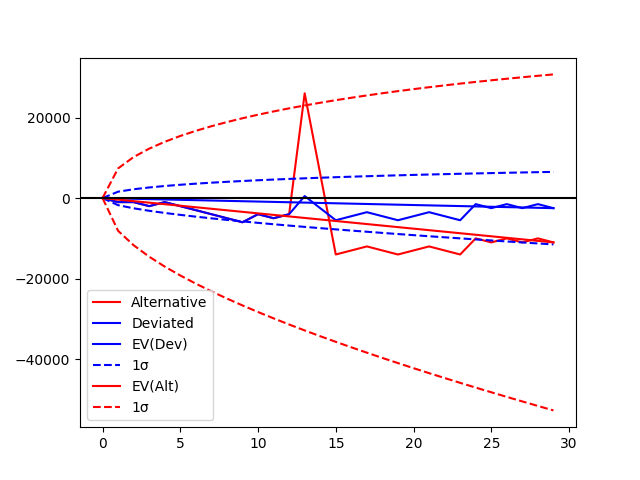

In [17]:
f, ax = plt.subplots()
ax.plot(cum_all_val_alt, color="red", label="Alternative")
ax.plot(cum_all_val_dev, color="blue", label="Deviated")

ax.plot(expected_win_dev, color="blue", label="EV(Dev)")
ax.plot(expected_win_dev + sigma_dev, color="blue", ls="--", label="1σ")
# ax.plot(expected_win_dev + 2 * sigma_dev, color="blue", ls=":", label="2σ")
ax.plot(expected_win_dev - sigma_dev, color="blue", ls="--")
# ax.plot(expected_win_dev - 2 * sigma_dev, color="blue", ls=":")

ax.plot(expected_win_alt, color="red", label="EV(Alt)")
ax.plot(expected_win_alt + sigma_alt, color="red", ls="--", label="1σ")
# ax.plot(expected_win_alt + 2 * sigma_alt, color="red", ls=":", label="2σ")
ax.plot(expected_win_alt - sigma_alt, color="red", ls="--")
# ax.plot(expected_win_alt - 2 * sigma_alt, color="red", ls=":")

ax.axhline(0, color="black")
ax.legend()

In [18]:
all_bet_values_dev_unit = np.array(all_values_dev) / 1000

In [19]:
true_count_dev = np.array(true_count_dev)

In [20]:
bet_sizes_dev = []
for tc in true_count_dev:
    tc_int = int(tc)
    if tc_int >= 5:
        bet_sizes_dev.append(10)
    elif tc_int >= 4:
        bet_sizes_dev.append(8)
    elif tc_int >= 3:
        bet_sizes_dev.append(6)
    elif tc_int >= 2:
        bet_sizes_dev.append(4)
    elif tc_int >= 1:
        bet_sizes_dev.append(2)
    else:
        bet_sizes_dev.append(1)

bet_sizes_dev = np.array(bet_sizes_dev)

In [21]:
all_bet_values_dev_unit_scaled = all_bet_values_dev_unit / bet_sizes_dev

In [22]:
tc_step = 0.5
tc_low = np.arange(true_count_dev.min(), true_count_dev.max(), tc_step)

av_wins = []
tc_mids = []
for tc_l in tc_low:
    tc_high = tc_l + tc_step
    tc_mid = tc_l + tc_step / 2
    idx = (true_count_dev < tc_high) & (true_count_dev >= tc_l)
    if sum(idx) < 30:
        continue
    av_win = all_bet_values_dev_unit_scaled[idx].mean()
    av_wins.append(av_win)
    tc_mids.append(tc_mid)

In [23]:
av_wins = np.array(av_wins)
tc_mids = np.array(tc_mids)

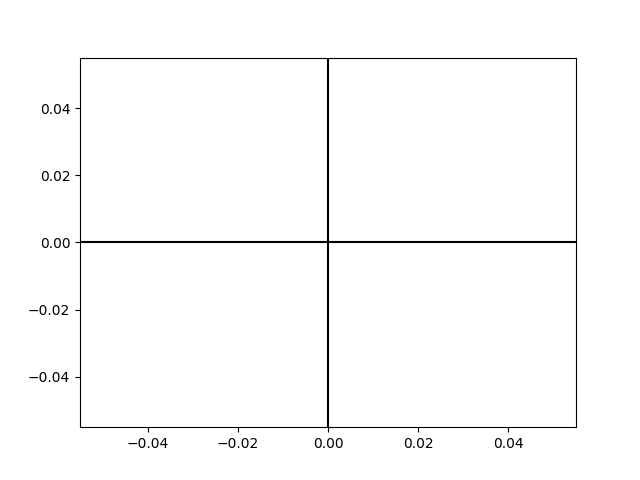

In [24]:
f, ax = plt.subplots()
ax.plot(tc_mids, av_wins)
ax.scatter(tc_mids[av_wins<=0], av_wins[av_wins<=0], color="red")
ax.scatter(tc_mids[av_wins>0], av_wins[av_wins>0], color="green")
ax.axhline(0, color="black")
ax.axvline(0, color="black")

In [25]:
import seaborn as sns

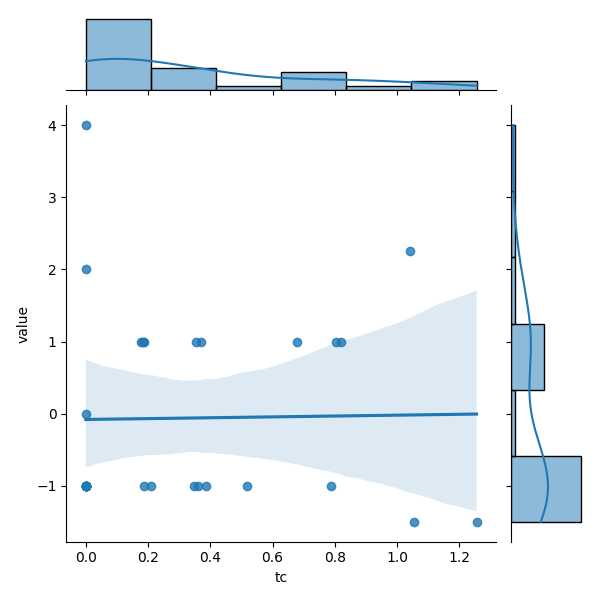

In [26]:
data = pd.DataFrame({"tc": true_count_dev, "value": all_bet_values_dev_unit / bet_sizes_dev})
sns.jointplot(data=data, y="value", x="tc", kind="reg")


In [27]:
# Calculate linear fit coefficients
from scipy import stats

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(true_count_dev, all_bet_values_dev_unit_scaled)

print(f"Linear Fit Coefficients:")
print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"R-squared: {r_value**2:.6f}")
print(f"P-value: {p_value:.2e}")
print(f"Standard Error: {std_err:.6f}")
print()
print(f"Equation: y = {slope:.6f} * TC + {intercept:.6f}")

Linear Fit Coefficients:
Slope: 0.059811
Intercept: -0.080374
R-squared: 0.000274
P-value: 9.32e-01
Standard Error: 0.695280

Equation: y = 0.059811 * TC + -0.080374


In [28]:
- intercept / slope

np.float64(1.343795136189873)

In [29]:
0.003845 / 0.004908 

0.7834148329258354

In [30]:
tc_idx = 0
tc_by_shoe = []

for v_by_shoe in values_by_shoe_dev:
    tc_idx_next = tc_idx + len(v_by_shoe) - 1
    tc_by_shoe.append(true_count_dev[tc_idx:tc_idx_next])
    tc_idx = tc_idx_next

In [31]:
ten_tc_by_shoe = np.zeros((len(tc_by_shoe), 10))
for i, tc_shoe in enumerate(tc_by_shoe):
    ten_tc_by_shoe[i, :] = tc_shoe[:10]

ValueError: could not broadcast input array from shape (5,) into shape (10,)

In [ ]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

sns.histplot(
    {"tc": ten_tc_by_shoe[:, 1]},
    x="tc",
    palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
)

In [ ]:
np.mean(ten_tc_by_shoe[:, 9] >= 0.5)

In [ ]:
np.mean(ten_tc_by_shoe[ten_tc_by_shoe[:, 3] >= 0.5, 9] >= 1)